# Part II - Vision Task (Plant Disease Classification)

Assessment coverage:
- Part A: Baseline CNN from scratch
- Part A: Deeper CNN + regularization + optimizer comparison + ablation
- Part B: Transfer learning with fine-tuning

> Notebook prepared only; not executed.

In [1]:
# Import core libraries
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
try:
    import seaborn as sns
    HAS_SEABORN = True
except Exception as e:
    sns = None
    HAS_SEABORN = False
    print('Seaborn unavailable, using matplotlib fallback:', e)
import tensorflow as tf
tf.get_logger().setLevel('ERROR')
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow version:', tf.__version__)
print('GPU devices found:', gpus)
USING_GPU = len(gpus) > 0
if USING_GPU:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('GPU enabled with memory growth.')
    except Exception as e:
        print('Could not set memory growth:', e)
else:
    print('Running on CPU. Training will be slower.')

tf.keras.mixed_precision.set_global_policy('float32')
print('Precision policy:', tf.keras.mixed_precision.global_policy())


TensorFlow version: 2.10.0
GPU devices found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
GPU enabled with memory growth.
Precision policy: <Policy "float32">


In [2]:
# Dataset path resolution for PlantVillage (Part 2)
from pathlib import Path

MANUAL_DATASET_DIR = r'C:/Users/DELL/OneDrive/Documents/AI/PlantVillage'

SEARCH_ROOTS = [
    Path(r'C:/Users/DELL/OneDrive/Documents/AI'),
    Path(r'C:/Users/DELL/Downloads'),
    Path(r'D:/'),
    Path(r'E:/'),
]

def looks_like_plantvillage_dataset(folder: Path):
    if not folder.exists() or not folder.is_dir():
        return False
    subdirs = [d for d in folder.iterdir() if d.is_dir()]
    if len(subdirs) < 5:
        return False
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    ok = 0
    for sd in subdirs[:30]:
        if any(f.is_file() and f.suffix.lower() in exts for f in sd.iterdir()):
            ok += 1
    return ok >= 5

DATASET_DIR = None
if MANUAL_DATASET_DIR.strip():
    mp = Path(MANUAL_DATASET_DIR)
    if looks_like_plantvillage_dataset(mp):
        DATASET_DIR = str(mp)

if DATASET_DIR is None:
    keywords = ('plantvillage', 'plant', 'disease')
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        for p in root.rglob('*'):
            if p.is_dir() and any(k in p.name.lower() for k in keywords):
                if looks_like_plantvillage_dataset(p):
                    DATASET_DIR = str(p)
                    break
        if DATASET_DIR:
            break

if DATASET_DIR is None:
    raise FileNotFoundError('PlantVillage dataset not found. Set MANUAL_DATASET_DIR to the folder containing class subfolders.')

print('Using dataset:', DATASET_DIR)


Using dataset: C:\Users\DELL\OneDrive\Documents\AI\PlantVillage


In [3]:
# Create train/validation datasets
IMG_SIZE = (96, 96)
BATCH_SIZE = 16
VAL_SPLIT = 0.2
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=VAL_SPLIT, subset='training', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR, validation_split=VAL_SPLIT, subset='validation', seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode='int'
)
class_names = train_ds.class_names
num_classes = len(class_names)

augment = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.06),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='plant_augment')

# collect labels
y_all = np.concatenate([y.numpy() for _, y in train_ds.unbatch().batch(8192)])

# count per class
label_counts = np.bincount(y_all, minlength=num_classes).astype(np.float32)
n = label_counts.sum()

# balanced class weights: total_samples / (num_classes * class_count)
raw_w = np.where(label_counts > 0, n / (num_classes * label_counts), 0.0)

# optional: normalize so mean weight over present classes = 1
present = label_counts > 0
raw_w[present] /= raw_w[present].mean()

class_weight = {i: float(raw_w[i]) for i in range(num_classes)}


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(3000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
print('Classes:', num_classes)
print('Class weights ready for training.')


Found 41951 files belonging to 16 classes.
Using 33561 files for training.
Found 41951 files belonging to 16 classes.
Using 8390 files for validation.
Classes: 16
Class weights ready for training.


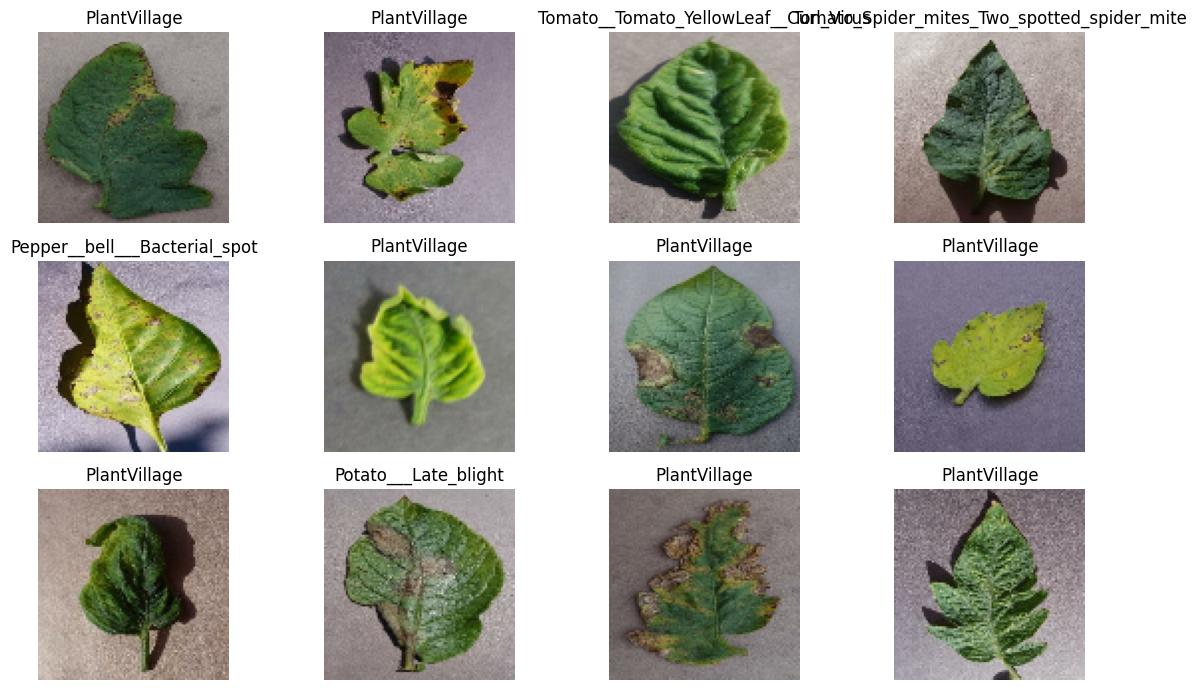

In [4]:
# Visual check: show sample images
plt.figure(figsize=(12, 7))  # Figure canvas
for images, labels in train_ds.take(1):  # Take one batch
    for i in range(min(12, len(images))):  # Plot up to 12 images
        ax = plt.subplot(3, 4, i + 1)  # Grid position
        plt.imshow(images[i].numpy().astype('uint8'))  # Render image
        plt.title(class_names[labels[i]])  # Class title
        plt.axis('off')  # Hide axis
plt.tight_layout()  # Spacing
plt.show()  # Display

In [5]:
# Data augmentation pipeline
aug = keras.Sequential([
    layers.RandomFlip('horizontal'),  # Random flip
    layers.RandomRotation(0.1),  # Small rotation
    layers.RandomZoom(0.1),  # Small zoom
], name='augmentation')  # Named pipeline

In [6]:
# Baseline CNN (3 conv+pool, 3 FC layers)
def build_baseline(input_shape, n_classes):  # Builder function
    m = Sequential(name='baseline_cnn')  # Sequential model
    m.add(layers.Input(shape=input_shape))  # Input
    m.add(aug)  # Augmentation
    m.add(layers.Rescaling(1./255.0))  # Normalize
    m.add(layers.Conv2D(32, 3, activation='relu', padding='same'))  # Conv 1
    m.add(layers.MaxPooling2D())  # Pool 1
    m.add(layers.Conv2D(64, 3, activation='relu', padding='same'))  # Conv 2
    m.add(layers.MaxPooling2D())  # Pool 2
    m.add(layers.Conv2D(128, 3, activation='relu', padding='same'))  # Conv 3
    m.add(layers.MaxPooling2D())  # Pool 3
    m.add(layers.Flatten())  # Flatten
    m.add(layers.Dense(256, activation='relu'))  # FC 1
    m.add(layers.Dense(128, activation='relu'))  # FC 2
    m.add(layers.Dense(64, activation='relu'))  # FC 3
    m.add(layers.Dense(n_classes, activation='softmax'))  # Output
    return m  # Return model
baseline = build_baseline(IMG_SIZE + (3,), num_classes)  # Instantiate baseline
baseline.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])  # Compile
baseline.summary()  # Show summary

Model: "baseline_cnn"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 augmentation (Sequential)   (None, 96, 96, 3)         0         
                                                                 
 rescaling (Rescaling)       (None, 96, 96, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 96, 96, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 48, 48, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 48, 48, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 24, 24, 64)       0         
 2D)                                                  

In [7]:
# Training toggles (all enabled as requested)
RUN_BASELINE = True
RUN_DEEPER_ADAM = True
RUN_DEEPER_SGD = True
RUN_ABLATION = True
RUN_TRANSFER = True

# Train baseline model
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint('best_part2_baseline.keras', monitor='val_accuracy', save_best_only=True),
]

base_loss = tf.keras.losses.SparseCategoricalCrossentropy()
baseline.compile(optimizer=Adam(3e-4), loss=base_loss, metrics=['accuracy'])

if RUN_BASELINE:
    t0 = time.time()
    history_base = baseline.fit(
        train_ds,
        validation_data=val_ds,
        epochs=12,
        callbacks=callbacks,
        class_weight=class_weight,
        verbose=1,
    )
    time_base = time.time() - t0
    print('Baseline training seconds:', round(time_base, 2))
else:
    history_base = None


Epoch 1/12
2098/2098 [==============================] - 340s 160ms/step - loss: 0.7956 - accuracy: 0.2588 - val_loss: 2.1430 - val_accuracy: 0.3229 - lr: 3.0000e-04
Epoch 2/12
2098/2098 [==============================] - 321s 153ms/step - loss: 0.4207 - accuracy: 0.3970 - val_loss: 2.1060 - val_accuracy: 0.3325 - lr: 3.0000e-04
Epoch 3/12
2098/2098 [==============================] - 334s 159ms/step - loss: 0.3286 - accuracy: 0.4299 - val_loss: 2.0512 - val_accuracy: 0.3738 - lr: 3.0000e-04
Epoch 4/12
2098/2098 [==============================] - 337s 161ms/step - loss: 0.2832 - accuracy: 0.4477 - val_loss: 1.9925 - val_accuracy: 0.4290 - lr: 3.0000e-04
Epoch 5/12
2098/2098 [==============================] - 338s 161ms/step - loss: 0.2535 - accuracy: 0.4582 - val_loss: 1.7944 - val_accuracy: 0.4257 - lr: 3.0000e-04
Epoch 6/12
2098/2098 [==============================] - 321s 153ms/step - loss: 0.2327 - accuracy: 0.4656 - val_loss: 1.7579 - val_accuracy: 0.4325 - lr: 3.0000e-04
Epoch 7/12

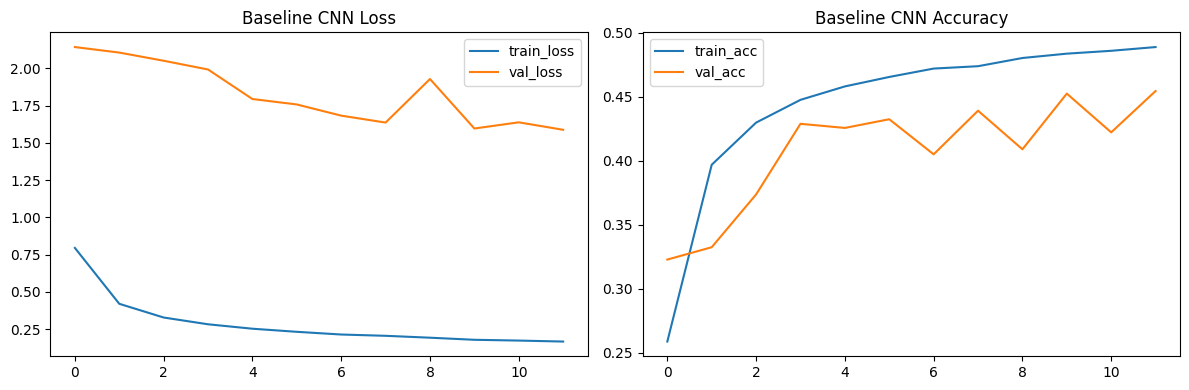

In [8]:
# Utility: plot history curves
def plot_history(h, title):
    if h is None or not hasattr(h, 'history'):
        print(f'Skipped plotting for {title}: no training history available.')
        return
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h.history.get('loss', []), label='train_loss')
    plt.plot(h.history.get('val_loss', []), label='val_loss')
    plt.title(title + ' Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h.history.get('accuracy', []), label='train_acc')
    plt.plot(h.history.get('val_accuracy', []), label='val_acc')
    plt.title(title + ' Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

# Plot only histories that were actually trained
plot_history(history_base, 'Baseline CNN')
if 'history_deeper_adam' in globals():
    plot_history(history_deeper_adam, 'Deeper CNN (Adam)')
if 'history_deeper_sgd' in globals():
    plot_history(history_deeper_sgd, 'Deeper CNN (SGD)')
if 'history_ablation' in globals():
    plot_history(history_ablation, 'Ablation (No Dropout)')
if 'history_tl1' in globals():
    plot_history(history_tl1, 'Transfer Stage 1')
if 'history_tl2' in globals():
    plot_history(history_tl2, 'Transfer Stage 2')



Baseline CNN: acc=0.4546, prec=0.4662, rec=0.4546, f1=0.3143
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.36      1.00      0.53       201
                     Pepper__bell___healthy       0.49      0.94      0.64       302
                               PlantVillage       0.47      0.01      0.02      4159
                      Potato___Early_blight       0.46      0.96      0.63       235
                       Potato___Late_blight       0.49      0.74      0.59       187
                           Potato___healthy       0.83      0.81      0.82       125
                      Tomato_Bacterial_spot       0.47      0.94      0.63       425
                        Tomato_Early_blight       0.34      0.96      0.50       210
                         Tomato_Late_blight       0.45      0.76      0.56       377
                           Tomato_Leaf_Mold       0.42      0.84      0.56       173
  

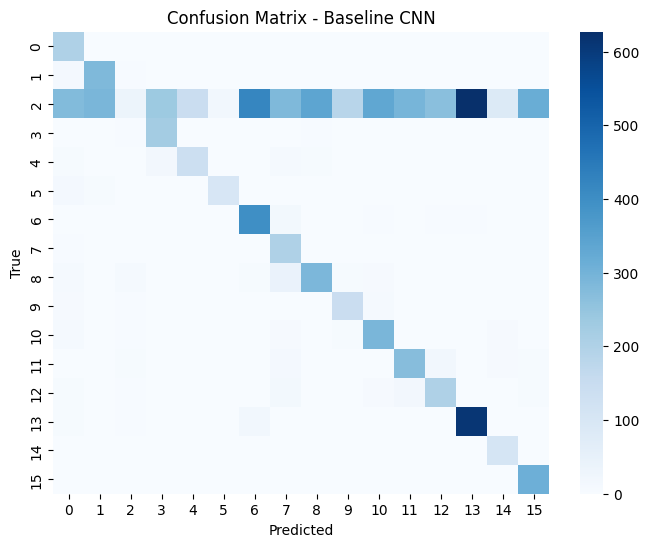

In [9]:
# Utility: evaluate a model with full metrics
def evaluate_model(model, dataset, classes, name):
    y_true, y_pred = [], []
    for xb, yb in dataset:
        p = model.predict(xb, verbose=0)
        y_true.extend(yb.numpy())
        y_pred.extend(np.argmax(p, axis=1))
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f'\n{name}: acc={acc:.4f}, prec={prec:.4f}, rec={rec:.4f}, f1={f1:.4f}')
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    if HAS_SEABORN:
        sns.heatmap(cm, cmap='Blues')
    else:
        plt.imshow(cm, cmap='Blues')
        plt.colorbar()
    plt.title('Confusion Matrix - ' + name)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

if RUN_BASELINE:
    metrics_base = evaluate_model(baseline, val_ds, class_names, 'Baseline CNN')
else:
    metrics_base = None
    print('Skipped baseline evaluation (RUN_BASELINE=False).')


Epoch 1/12
2098/2098 [==============================] - 282s 133ms/step - loss: 1.8285 - accuracy: 0.4762 - val_loss: 1.3908 - val_accuracy: 0.4886 - lr: 0.0010
Epoch 2/12
2098/2098 [==============================] - 298s 142ms/step - loss: 1.3768 - accuracy: 0.4782 - val_loss: 1.3845 - val_accuracy: 0.4656 - lr: 0.0010
Epoch 3/12
2098/2098 [==============================] - 283s 135ms/step - loss: 1.2005 - accuracy: 0.4837 - val_loss: 1.3592 - val_accuracy: 0.4877 - lr: 0.0010
Epoch 4/12
2098/2098 [==============================] - 319s 152ms/step - loss: 1.1285 - accuracy: 0.4865 - val_loss: 1.0665 - val_accuracy: 0.5010 - lr: 0.0010
Epoch 5/12
2098/2098 [==============================] - 299s 142ms/step - loss: 1.0738 - accuracy: 0.4907 - val_loss: 1.2664 - val_accuracy: 0.4963 - lr: 0.0010
Epoch 6/12
2098/2098 [==============================] - 322s 153ms/step - loss: 1.0447 - accuracy: 0.4916 - val_loss: 1.1765 - val_accuracy: 0.4918 - lr: 0.0010
Epoch 7/12
2098/2098 [============

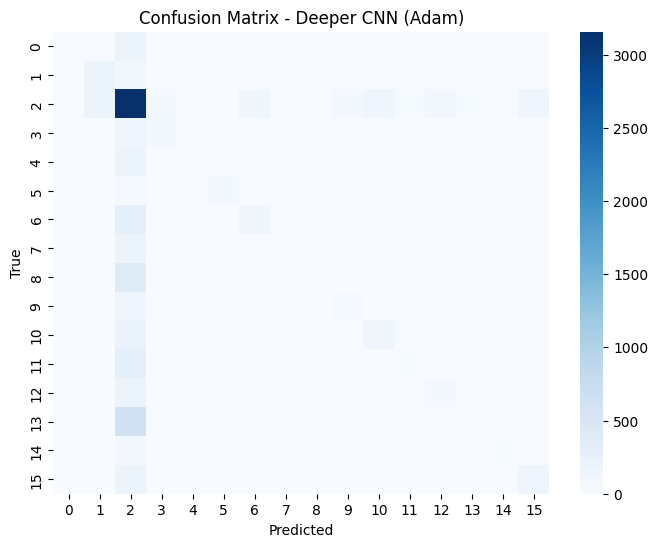

In [10]:
# Deeper CNN with regularization (more conv layers + BN + Dropout)
def build_deeper(input_shape, n_classes):
    m = Sequential(name='deeper_cnn')
    m.add(layers.Input(shape=input_shape))
    m.add(aug)
    m.add(layers.Rescaling(1./255.0))
    m.add(layers.Conv2D(32, 3, padding='same', activation='relu'))
    m.add(layers.BatchNormalization())
    m.add(layers.Conv2D(32, 3, padding='same', activation='relu'))
    m.add(layers.MaxPooling2D())
    m.add(layers.Dropout(0.2))
    m.add(layers.Conv2D(64, 3, padding='same', activation='relu'))
    m.add(layers.BatchNormalization())
    m.add(layers.Conv2D(64, 3, padding='same', activation='relu'))
    m.add(layers.MaxPooling2D())
    m.add(layers.Dropout(0.25))
    m.add(layers.Conv2D(128, 3, padding='same', activation='relu'))
    m.add(layers.BatchNormalization())
    m.add(layers.Conv2D(128, 3, padding='same', activation='relu'))
    m.add(layers.MaxPooling2D())
    m.add(layers.Dropout(0.3))
    m.add(layers.Flatten())
    m.add(layers.Dense(512, activation='relu'))
    m.add(layers.Dropout(0.4))
    m.add(layers.Dense(256, activation='relu'))
    m.add(layers.Dense(128, activation='relu'))
    m.add(layers.Dense(n_classes, activation='softmax'))
    return m

if RUN_DEEPER_ADAM:
    deeper_adam = build_deeper(IMG_SIZE + (3,), num_classes)
    deeper_adam.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history_deeper_adam = deeper_adam.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks, verbose=1)
    metrics_deeper_adam = evaluate_model(deeper_adam, val_ds, class_names, 'Deeper CNN (Adam)')
else:
    metrics_deeper_adam = None
    print('Skipped Deeper CNN (Adam) (RUN_DEEPER_ADAM=False).')


In [1]:
# Optimizer analysis: same deeper architecture trained with SGD
if RUN_DEEPER_SGD:
    deeper_sgd = build_deeper(IMG_SIZE + (3,), num_classes)
    deeper_sgd.compile(optimizer=SGD(learning_rate=1e-2, momentum=0.9), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history_deeper_sgd = deeper_sgd.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks, verbose=1)
    metrics_deeper_sgd = evaluate_model(deeper_sgd, val_ds, class_names, 'Deeper CNN (SGD)')
else:
    metrics_deeper_sgd = None
    print('Skipped Deeper CNN (SGD) (RUN_DEEPER_SGD=False).')


NameError: name 'RUN_DEEPER_SGD' is not defined

In [ ]:
# Ablation study: remove dropout layers and compare
def build_deeper_no_dropout(input_shape, n_classes):
    m = Sequential(name='deeper_no_dropout')
    m.add(layers.Input(shape=input_shape))
    m.add(aug)
    m.add(layers.Rescaling(1./255.0))
    for f in [32, 32, 64, 64, 128, 128]:
        m.add(layers.Conv2D(f, 3, padding='same', activation='relu'))
        if f in [32, 64, 128]:
            m.add(layers.BatchNormalization())
        if f in [32, 64, 128]:
            m.add(layers.MaxPooling2D())
    m.add(layers.Flatten())
    m.add(layers.Dense(512, activation='relu'))
    m.add(layers.Dense(256, activation='relu'))
    m.add(layers.Dense(128, activation='relu'))
    m.add(layers.Dense(n_classes, activation='softmax'))
    return m

if RUN_ABLATION:
    ablation = build_deeper_no_dropout(IMG_SIZE + (3,), num_classes)
    ablation.compile(optimizer=Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history_ablation = ablation.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks, verbose=1)
    metrics_ablation = evaluate_model(ablation, val_ds, class_names, 'Ablation (No Dropout)')
else:
    metrics_ablation = None
    print('Skipped ablation study (RUN_ABLATION=False).')


In [ ]:
# Part B: Transfer learning for PlantVillage (DirectML tuned, target: >=65%)
if RUN_TRANSFER:
    train_tl = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR, validation_split=VAL_SPLIT, subset='training', seed=SEED,
        image_size=(224, 224), batch_size=32, label_mode='int'
    )
    val_tl = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR, validation_split=VAL_SPLIT, subset='validation', seed=SEED,
        image_size=(224, 224), batch_size=32, label_mode='int'
    )

    augment_tl = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.04),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.08),
    ], name='plant_augment_tl')

    y_tl_all = np.concatenate([y.numpy() for _, y in train_tl.unbatch().batch(8192)])
    tl_counts = np.bincount(y_tl_all, minlength=num_classes).astype(np.float32)
    total_tl = tl_counts.sum()
    raw_w_tl = np.where(tl_counts > 0, total_tl / (num_classes * tl_counts), 0.0)
    present_tl = tl_counts > 0
    raw_w_tl[present_tl] /= raw_w_tl[present_tl].mean()
    raw_w_tl = np.clip(raw_w_tl, 0.5, 3.0)
    class_weight_tl = {i: float(raw_w_tl[i]) for i in range(num_classes)}

    train_tl = train_tl.shuffle(5000).cache().prefetch(tf.data.AUTOTUNE)
    val_tl = val_tl.cache().prefetch(tf.data.AUTOTUNE)

    base = tf.keras.applications.EfficientNetB0(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
    base.trainable = False

    inp = keras.Input(shape=(224, 224, 3))
    x = augment_tl(inp)
    x = tf.keras.applications.efficientnet.preprocess_input(x)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    transfer = Model(inp, out, name='efficientnetb0_plantvillage_directml')

    loss_tl = tf.keras.losses.SparseCategoricalCrossentropy(label_smoothing=0.03)
    callbacks_tl = [
        EarlyStopping(monitor='val_accuracy', patience=6, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=5e-7),
        tf.keras.callbacks.ModelCheckpoint('best_part2_transfer.keras', monitor='val_accuracy', save_best_only=True),
    ]

    transfer.compile(optimizer=Adam(3e-4), loss=loss_tl, metrics=['accuracy'])
    history_tl1 = transfer.fit(
        train_tl, validation_data=val_tl, epochs=10, callbacks=callbacks_tl, class_weight=class_weight_tl, verbose=1
    )

    base.trainable = True
    for layer in base.layers[:-80]:
        layer.trainable = False
    transfer.compile(optimizer=Adam(1e-5), loss=loss_tl, metrics=['accuracy'])
    history_tl2 = transfer.fit(
        train_tl, validation_data=val_tl, epochs=16, callbacks=callbacks_tl, class_weight=class_weight_tl, verbose=1
    )

    metrics_transfer = evaluate_model(transfer, val_tl, class_names, 'Transfer Learning (EfficientNetB0 DirectML)')
else:
    history_tl1 = None
    history_tl2 = None
    metrics_transfer = None
    print('Skipped transfer learning (RUN_TRANSFER=False).')


In [ ]:
# Summary table for report
rows = []
if metrics_base is not None:
    rows.append({'model': 'Baseline CNN', **metrics_base})
if metrics_deeper_adam is not None:
    rows.append({'model': 'Deeper CNN (Adam)', **metrics_deeper_adam})
if metrics_deeper_sgd is not None:
    rows.append({'model': 'Deeper CNN (SGD)', **metrics_deeper_sgd})
if metrics_ablation is not None:
    rows.append({'model': 'Ablation (No Dropout)', **metrics_ablation})
if metrics_transfer is not None:
    rows.append({'model': 'Transfer Learning', **metrics_transfer})

summary = pd.DataFrame(rows)
display(summary)
summary.to_csv('part2_metrics_summary.csv', index=False)
